In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import ollama


sys.path.append(os.path.abspath('..')) 


from src.processing.nlp_extractors import ScholarshipDataProcessor


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


tqdm.pandas(desc="Processing NLP Pipeline")

In [3]:
print(">>> Loading Raw Data...")
all_data = []

folder_path = '../data_Json' 

file_paths = glob.glob(os.path.join(folder_path, '*_scholarships_data*.json'))
for file_path in file_paths:
    try:
        df_temp = pd.read_json(file_path)
        df_temp['source_file'] = os.path.basename(file_path)
        all_data.append(df_temp)
    except Exception as e:
        print(f"Error loading {os.path.basename(file_path)}: {e}")

df_raw = pd.concat(all_data, ignore_index=True)
print(f" Total records loaded: {len(df_raw)}")
df_raw.head(2)

>>> Loading Raw Data...
 Total records loaded: 2526


,scholarship_name,country,degree_level,funding_type,awards_available,deadline,tags,description,scholarship_details,eligibility,application_process,application_link,source_file
0,International Titanium Association Scholarship...,USA,Computer Science,"$4,000",3,"May 14, 2026","[GPA, Selected Major(s), Current Year in Schoo...","The International Titanium Association, a non-...",N/A,N/A,N/A,https://www.scholarships.com/scholarships/inte...,computer_science_scholarships_data.json
1,Eye-Bank for Sight Restoration STEM Scholarship,USA,Computer Science,"$3,000",1,"May 15, 2026","[State Selection, Selected Major(s), Current Y...",The Eye-Bank together with the Fabian family c...,"$3,000 scholarship awarded annually\nOpen to u...",Must reside in The Eye-Bank’s service area: Ne...,Visit www.eyedonation.org/scholarship/stem to ...,https://www.scholarships.com/scholarships/eye-...,computer_science_scholarships_data.json


### funding_type & degree_level	

In [17]:
print(">>> Initializing the NLP Processor...")
processor = ScholarshipDataProcessor(use_zero_shot=False)

print(">>> Extracting Funding Data...")
df_raw[['funding_category', 'funding_amount']] = df_raw.progress_apply(processor.process_funding, axis=1)

print(">>> Extracting Degree Levels...")
df_raw['academic_level'] = df_raw.progress_apply(processor.process_degree_level, axis=1)['academic_level']

print(">>> Extracting Academic Majors via LLM...")
df_raw['academic_major'] = df_raw.progress_apply(processor.process_academic_major, axis=1)['academic_major']

print("Processing Complete!")

INFO: Initializing NLP Models...


>>> Initializing the NLP Processor...


>>> Extracting Funding Data...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

>>> Extracting Degree Levels...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

>>> Extracting Academic Majors via LLM...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO: HTTP Request: POST 

Processing Complete!


In [18]:
total_rows = len(df_raw)

unspecified_level = (df_raw['academic_level'] == 'Unspecified').sum()
unspecified_major = (df_raw['academic_major'] == 'Unspecified').sum()
unspecified_funding = (df_raw['funding_category'] == 'Variable / Unspecified').sum()

print("--- Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Academic Level Extraction Failure: {unspecified_level} records ({(unspecified_level/total_rows)*100:.1f}%)")
print(f"Academic Major Extraction Failure: {unspecified_major} records ({(unspecified_major/total_rows)*100:.1f}%)")
print(f"Funding Category Extraction Failure: {unspecified_funding} records ({(unspecified_funding/total_rows)*100:.1f}%)")

if unspecified_level > 0:
    print("\n--- Sample of Failed Academic Levels ---")
    display(df_raw[df_raw['academic_level'] == 'Unspecified'][['scholarship_name', 'description']].head())

if unspecified_major > 0:
    print("\n--- Sample of Failed Academic Majors ---")
    display(df_raw[df_raw['academic_major'] == 'Unspecified'][['scholarship_name', 'description']].head())

--- Extraction Quality Report ---
Total Processed: 2526
Academic Level Extraction Failure: 169 records (6.7%)
Academic Major Extraction Failure: 107 records (4.2%)
Funding Category Extraction Failure: 166 records (6.6%)

--- Sample of Failed Academic Levels ---


,scholarship_name,description
0,International Titanium Association Scholarship...,"The International Titanium Association, a non-..."
5,Reason One Mentorship and Scholarship Program,The Reason One Mentorship & Scholarship Progra...
7,Betty Stevens-Frecknall Scholarship,The Betty Stevens-Frecknall Scholarship is a p...
10,Project STEM Heroes Scholarship,"""You are the solution."" Inspired by the movie ..."
12,SBB Research Group STEM Scholarship,The SBB Research Group STEM Scholarship encour...



--- Sample of Failed Academic Majors ---


,scholarship_name,description
28,Cindy Finley Memorial Scholarship for Women in...,To honor the legacy of our friend and fellow F...
166,Elevate Scholarship Program,Elevate is giving away scholarships to high sc...
190,4-H Youth in Action Scholarship,The 4-H Youth in Action program highlights the...
318,LinkedIn Possibilities in Tech Scholarship,"At LinkedIn, one of our core values is to “Dre..."
333,Tailhook Educational Foundation (TEF) Scholars...,The Tailhook Educational Foundation (TEF) is a...


In [24]:
import textwrap

print(">>> AI Major Extraction Quality Assurance (QA) Sample <<<\n")

extracted_majors = df_raw[~df_raw['academic_major'].isin(['Unspecified', 'All Disciplines'])]

qa_sample = extracted_majors.sample(5)

for index, row in qa_sample.iterrows():
    print(f"Scholarship: {row['scholarship_name']}")
    print(f"Extracted Major: {row['academic_major']}")
    
    context = str(row.get('description', '')) + " " + str(row.get('scholarship_details', ''))
    
    short_context = textwrap.shorten(context, width=400, placeholder=" ...")
    print(f"Context Snippet: \n{short_context}")
    print("-" * 80)

>>> AI Major Extraction Quality Assurance (QA) Sample <<<

Scholarship: ASNE Scholarship Program
Extracted Major: Engineering
Context Snippet: 
The American Society of Naval Engineers began its scholarship program in 1979 in order to promote the profession of naval engineering and to encourage college students to enter the field. Since the inception of the Scholarship Program, ASNE has since awarded hundreds of scholarships to undergraduate and graduate students interested in pursuing an education and career in naval engineering. N/A
--------------------------------------------------------------------------------
Scholarship: Alexander von Humboldt Foundation: Hezekiah Wardwell Fellowship (Saudi Arabia - Undergraduates)
Extracted Major: music, musicology
Context Snippet: 
--- Programme Description --- The Alexander von Humboldt Foundation awards each year up to 10 fellowships to highly gifted young musicians and musicologists from Spain to help finance their further training or advance

/tmp/ipykernel_5254/1785376926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
/tmp/ipykernel_5254/1785376926.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
/tmp/ipykernel_5254/1785376926.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='funding_category', ax=axes[2], pal

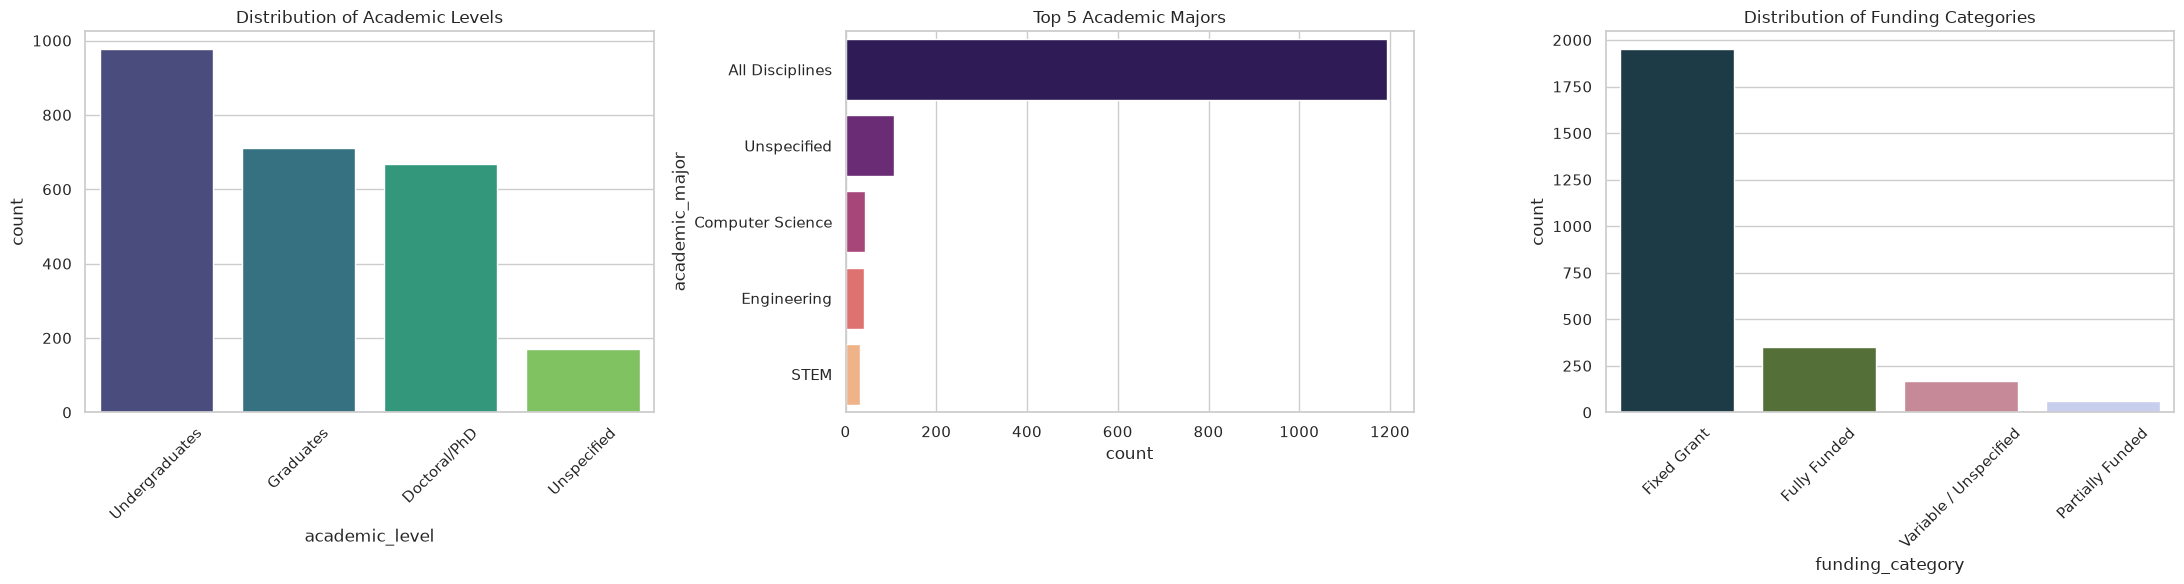

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))


sns.countplot(data=df_raw, x='academic_level', ax=axes[0], palette="viridis", order=df_raw['academic_level'].value_counts().index)
axes[0].set_title('Distribution of Academic Levels')
axes[0].tick_params(axis='x', rotation=45)


top_majors = df_raw['academic_major'].value_counts().nlargest(5).index
sns.countplot(data=df_raw[df_raw['academic_major'].isin(top_majors)], y='academic_major', ax=axes[1], palette="magma", order=top_majors)
axes[1].set_title('Top 5 Academic Majors')


sns.countplot(data=df_raw, x='funding_category', ax=axes[2], palette="cubehelix", order=df_raw['funding_category'].value_counts().index)
axes[2].set_title('Distribution of Funding Categories')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
print("--- 1. Academic Level Distribution ---")

level_dist = df_raw['academic_level'].value_counts()
level_pct = df_raw['academic_level'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': level_dist, 'Percentage %': level_pct.round(2)})
display(dist_df)

print("--- 1. Academic Major Distribution ---")

major_dist = df_raw['academic_major'].value_counts()
major_pct = df_raw['academic_major'].value_counts(normalize=True) * 100
dist_major_df = pd.DataFrame({'Count': major_dist, 'Percentage %': major_pct.round(2)})
display(dist_major_df)

print("\n--- 2. Funding Category Distribution ---")

funding_dist = df_raw['funding_category'].value_counts()
funding_pct = df_raw['funding_category'].value_counts(normalize=True) * 100
dist_funding_df = pd.DataFrame({'Count': funding_dist, 'Percentage %': funding_pct.round(2)})
display(dist_funding_df)

--- 1. Academic Level Distribution ---


,Count,Percentage %
academic_level,,
Undergraduates,976,38.64
Graduates,712,28.19
Doctoral/PhD,669,26.48
Unspecified,169,6.69


--- 1. Academic Major Distribution ---


,Count,Percentage %
academic_major,,
All Disciplines,1193,47.23
Unspecified,107,4.24
Computer Science,43,1.70
Engineering,41,1.62
STEM,31,1.23
...,...,...
"visual communication,photography,illustration,graphic design",1,0.04
"marketing, advertising, web development, graphic design, journalism, creative writing, entrepreneurship",1,0.04
"Technology-related courses, training",1,0.04



--- 2. Funding Category Distribution ---


,Count,Percentage %
funding_category,,
Fixed Grant,1949,77.16
Fully Funded,351,13.90
Variable / Unspecified,166,6.57
Partially Funded,60,2.38


In [22]:
print("--- QA: Academic Level Extraction Verification ---")

valid_levels = df_raw[df_raw['academic_level'] != 'Unspecified'].copy()


sample_levels = valid_levels.sample(frac=1, random_state=42).groupby('academic_level').head(20)


display(sample_levels[['scholarship_name', 'description', 'academic_level', 'academic_major','tags']])

print("\n--- QA: Funding Extraction Verification ---")

valid_funding = df_raw[df_raw['funding_category'] != 'Variable / Unspecified'].copy()


sample_funding = valid_funding.sample(frac=1, random_state=42).groupby('funding_category').head(10)


display(sample_funding[['funding_type', 'funding_category', 'funding_amount']])

--- QA: Academic Level Extraction Verification ---


,scholarship_name,description,academic_level,academic_major,tags
1798,SBW Berlin Scholarship (Saudi Arabia - Undergr...,---\nProgramme Description\n---\nThe SBW Berli...,Undergraduates,All Disciplines,"[DAAD, Saudi Arabia, Undergraduates, Germany]"
1221,Munich Aerospace: PhD Scholarships (Jordan - D...,---\nProgramme Description\n---\nThe Munich Ae...,Doctoral/PhD,Aeronautics,"[DAAD, Jordan, Doctoral candidates/PhD student..."
1752,Combined Study and Practice Stays for Engineer...,The scholarships offer students from Indian In...,Doctoral/PhD,"Engineering, Mathematics and Natural Sciences","[DAAD, Saudi Arabia, Doctoral candidates/PhD s..."
2270,German-Czech Fund for the Future: Grants for S...,---\nProgramme Description\n---\nThe German-Cz...,Graduates,All Disciplines,"[DAAD, Egypt, Graduates, Germany]"
242,Boeing Engineering Internship Program,"At Boeing, we innovate and collaborate to make...",Undergraduates,"Engineering, Computer Science, Technology, Sci...","[GPA, Selected Major(s), Current Year in Schoo..."
1946,Catholic Academic Exchange Service (KAAD): Sch...,---\nProgramme Description\n---\nThe KAAD is t...,Graduates,All Disciplines,"[DAAD, Egypt, Graduates, Germany]"
1285,Bilateral Exchange of Academics (to Germany) (...,To improve international relations and bilater...,Undergraduates,All Disciplines,"[DAAD, Egypt, Undergraduates, Germany]"
580,In-Region Scholarships for Postgraduate Studie...,"The programme aims at fostering strong, intern...",Undergraduates,Unspecified,"[DAAD, Syria, Undergraduates, Germany]"
1803,Doctoral Programmes in Germany (Egypt - Doctor...,This scholarship programme offers you the oppo...,Doctoral/PhD,"Human Medicine, Veterinary Medicine, Dentistry","[DAAD, Egypt, Doctoral candidates/PhD students..."
1631,In-Country/In Region Scholarships Programme at...,"The programme aims at fostering strong, intern...",Graduates,Atmospheric and Oceanic Science and Technology,"[DAAD, Saudi Arabia, Graduates, Germany]"



--- QA: Funding Extraction Verification ---


,funding_type,funding_category,funding_amount
658,Fully/Partially Funded (Check Details),Fixed Grant,300 eur
537,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
2376,Fully/Partially Funded (Check Details),Fixed Grant,992 eur
2097,Fully/Partially Funded (Check Details),Fixed Grant,"1,000 eur"
1678,Fully/Partially Funded (Check Details),Fixed Grant,€992
228,"$3,000",Fixed Grant,"$3,000"
1697,Fully/Partially Funded (Check Details),Fixed Grant,"2,300 eur"
270,"$1,500",Fixed Grant,"$1,500"
1231,Fully/Partially Funded (Check Details),Fixed Grant,"10,000 eur"
705,Fully/Partially Funded (Check Details),Fixed Grant,1.400 eur


### country

In [9]:
print(">>> Extracting Host Countries and Eligible Nationalities...")
df_raw[['host_country', 'eligible_nationality']] = df_raw.progress_apply(processor.process_country, axis=1)
print("Extraction Complete!")

>>> Extracting Host Countries and Eligible Nationalities...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

Extraction Complete!


In [10]:
total_rows = len(df_raw)

# Calculate missing or default values
unspecified_host = (df_raw['host_country'] == 'Unspecified').sum()
international_nat = (df_raw['eligible_nationality'] == 'International / All').sum()

print("--- Location Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Host Country Not Found (Unspecified): {unspecified_host} records ({(unspecified_host/total_rows)*100:.1f}%)")
print(f"Eligible Nationality (Defaulted to International): {international_nat} records ({(international_nat/total_rows)*100:.1f}%)")

# Display a sample of records where host country failed
if unspecified_host > 0:
    print("\n--- Sample of Failed Host Country Extractions ---")
    display(df_raw[df_raw['host_country'] == 'Unspecified'][['scholarship_name', 'country', 'description']].head())

--- Location Extraction Quality Report ---
Total Processed: 2526
Host Country Not Found (Unspecified): 0 records (0.0%)
Eligible Nationality (Defaulted to International): 488 records (19.3%)


In [ ]:
print("--- QA: Host Country and Nationality Verification ---")

# Filter out rows where host country is unspecified to verify successful extractions
valid_locations = df_raw[df_raw['host_country'] != 'Germany'].copy()

# Take a randomized sample grouped by host country
sample_locations = valid_locations.sample(frac=1, random_state=42).groupby('host_country').head(10)

# Display the raw country column alongside the extracted features
display(sample_locations[['scholarship_name', 'country', 'host_country', 'eligible_nationality']].head(15))

--- QA: Host Country and Nationality Verification ---


,scholarship_name,country,host_country,eligible_nationality
222,Hedy Lamarr Achievement Award,USA,USA,International / All
131,Asama Coldwater Manufacturing (ACM) Georgia Sc...,USA,USA,International / All
149,PG&E Better Together STEM Scholarship Program,USA,USA,International / All
244,Center for Women In Technology (CWIT) Scholars...,USA,USA,International / All
84,Quad City Engineering and Science Council Scho...,USA,USA,International / All
376,U.S. Western Digital STEM Scholarship,USA,USA,International / All
6,Kathy Pace Technology Scholarship,USA,USA,International / All
476,TEDS Faithful Future Scholarship,USA,USA,International / All
2508,BHW Scholarship,USA,USA,International / All
55,National Defense Science & Engineering Graduat...,USA,USA,International / All


/tmp/ipykernel_5254/3365733669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_5254/3365733669.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")


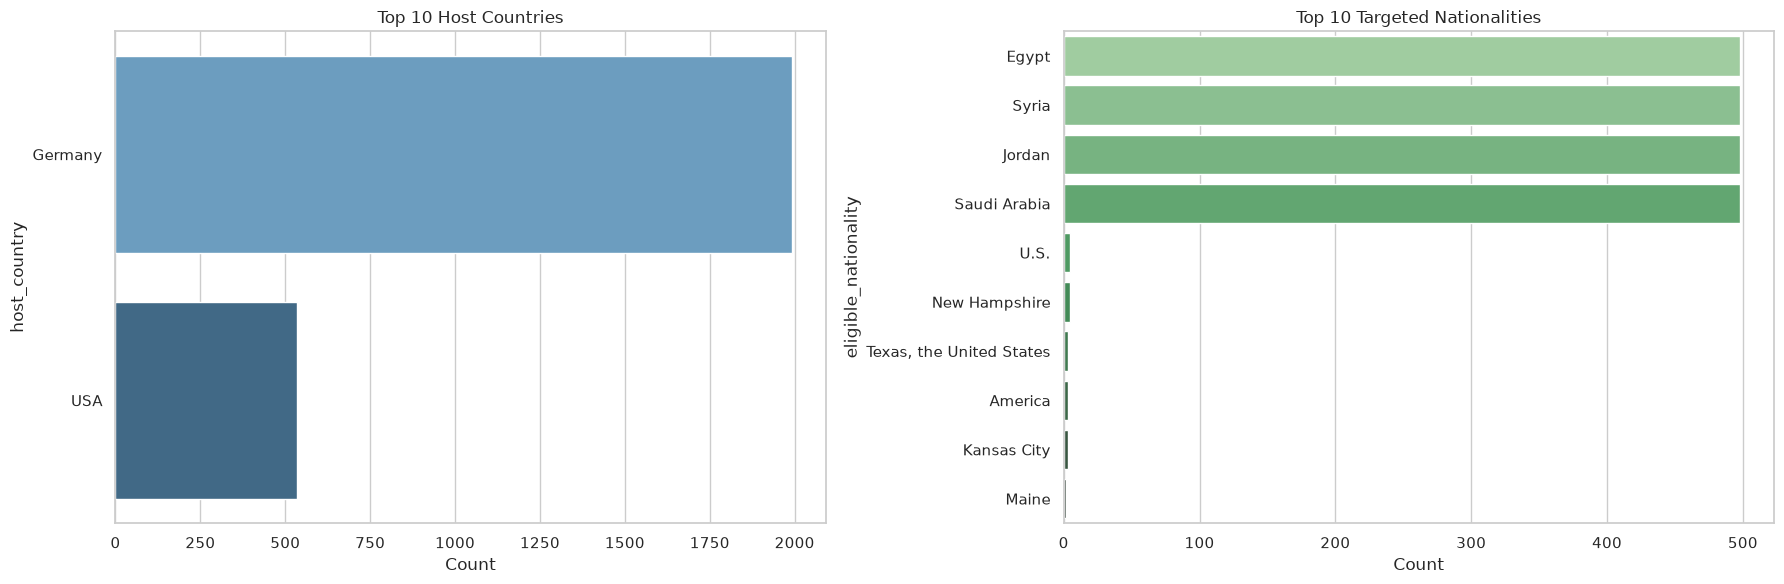

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Top 10 Host Countries
# Exclude 'Unspecified' for a cleaner chart
top_hosts = df_raw[df_raw['host_country'] != 'Unspecified']['host_country'].value_counts().nlargest(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, ax=axes[0], palette="Blues_d")
axes[0].set_title('Top 10 Host Countries')
axes[0].set_xlabel('Count')

# 2. Top 10 Restricted Eligible Nationalities
# Exclude 'International / All' to see which specific countries are targeted
top_nats = df_raw[df_raw['eligible_nationality'] != 'International / All']['eligible_nationality'].value_counts().nlargest(10)
if not top_nats.empty:
    sns.barplot(x=top_nats.values, y=top_nats.index, ax=axes[1], palette="Greens_d")
    axes[1].set_title('Top 10 Targeted Nationalities')
    axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Restricted Nationalities Found', horizontalalignment='center', verticalalignment='center')
    axes[1].set_title('Top 10 Targeted Nationalities')

plt.tight_layout()
plt.show()

### deadline

In [13]:
df_raw['deadline'].value_counts()

deadline
Not Specified                                                                                                                                                                                                                                                                                                                                1512
Varies                                                                                                                                                                                                                                                                                                                                         51
May 01, 2027                                                                                                                                                                                                                                                                                                               

In [14]:
import pandas as pd
import requests
import ollama
from src.processing.nlp_extractors import ScholarshipDataProcessor

print(">>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...")
processor = ScholarshipDataProcessor(use_zero_shot=False)

# ---------------------------------------------------------
# NEW: Sanity check to ensure Ollama and Qwen are running
# ---------------------------------------------------------
print(">>> Checking Local LLM Status...")
try:
    response = requests.get("http://localhost:11434/api/tags", timeout=5)
    if response.status_code == 200:
        if 'qwen2.5:7b' in response.text or 'qwen2.5' in response.text:
            print("SUCCESS: Ollama is running and Qwen-2.5 is available.")
        else:
            print("WARNING: Ollama is running, but Qwen-2.5 was not found. Please run: 'ollama run qwen2.5:7b' in terminal.")
    else:
        print(f"WARNING: Ollama returned unexpected status code: {response.status_code}")
except requests.ConnectionError:
    print("ERROR: Ollama is not running! Please open the Ollama application before proceeding.")

# ---------------------------------------------------------
# Execution and Analysis
# ---------------------------------------------------------
print("\n>>> Extracting Deadlines with Hybrid Engine...")
df_raw['standardized_deadline'] = df_raw.progress_apply(processor.process_deadline, axis=1)['standardized_deadline']

# Calculate metrics
total_rows = len(df_raw)
specified = (df_raw['standardized_deadline'] != 'Not Specified').sum()
missing = total_rows - specified

# Print Quality Report
print("\n--- Deadline Extraction Quality Report ---")
print(f"Total Processed: {total_rows}")
print(f"Dates Successfully Standardized: {specified} ({(specified/total_rows)*100:.1f}%)")
print(f"Remaining Missing/Varies: {missing} ({(missing/total_rows)*100:.1f}%)")

# Comprehensive Before & After Analysis
print("\n--- Comprehensive Analysis: Before & After Mapping ---")

# Group by the original deadline and the new standardized deadline to show all variations
mapping_analysis = df_raw.groupby(['deadline', 'standardized_deadline']).size().reset_index(name='frequency_count')

# Sort by frequency to see the most common transformations first
mapping_analysis = mapping_analysis.sort_values(by='frequency_count', ascending=False)

# Set Pandas options to display the full text and more rows for a comprehensive view
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 150)

# Display the complete mapping analysis
display(mapping_analysis)

# Reset Pandas view options to avoid affecting other cells
pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')

INFO: Initializing NLP Models...


>>> Initializing updated ScholarshipDataProcessor (Ollama Edition)...


>>> Checking Local LLM Status...
ERROR: Ollama is not running! Please open the Ollama application before proceeding.

>>> Extracting Deadlines with Hybrid Engine...


Processing NLP Pipeline:   0%|          | 0/2526 [00:00<?, ?it/s]

ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollam

ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download
ERROR: Local LLM Error: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollam


--- Deadline Extraction Quality Report ---
Total Processed: 2526
Dates Successfully Standardized: 483 (19.1%)
Remaining Missing/Varies: 2043 (80.9%)

--- Comprehensive Analysis: Before & After Mapping ---


,deadline,standardized_deadline,frequency_count
138,Not Specified,Not Specified,1512
160,Varies,Not Specified,51
125,"May 01, 2027",2027-05-01,33
19,"Application deadlines are updated annually in the second quarter. In most cases, they are in the same period as the previous year. You can find the current dates here: | 03.09.2025 | Selection decision in February 2026. Funding starts in May 2026. | 11.03.2026 | Selection decision in June 2026. Funding starts in September 2026.",Not Specified,24
15,"Application deadlines are updated annually in the second quarter. In most cases, they are in the same period as the previous year. You can find the current dates here: | 03.09.2025 | Funding decision will be taken in February 2026. Start of funding: October 2026",Not Specified,24
...,...,...,...
147,"October 07, 2026",2026-10-07,1
151,"October 31, 2026",2026-10-31,1
155,"September 18, 2026",2026-09-18,1
153,"September 10, 2026",2026-09-10,1


In [15]:

mapping_analysis.to_csv("deadline_mapping_grouped.csv", index=False)
print("Saved grouped mapping to: deadline_mapping_grouped.csv")


qa_df = df_raw[['scholarship_name', 'deadline', 'standardized_deadline']]
qa_df.to_csv("deadline_qa_full_comparison.csv", index=False)
print("Saved full row-by-row comparison to: deadline_qa_full_comparison.csv")

Saved grouped mapping to: deadline_mapping_grouped.csv
Saved full row-by-row comparison to: deadline_qa_full_comparison.csv


In [16]:
import textwrap

print(">>> AI Extraction Quality Assurance (QA) Sample <<<\n")

# فلترة المنح التي كانت مفقودة وتم استخراج تاريخ لها بنجاح
recovered_deadlines = df_raw[(df_raw['deadline'].str.lower().isin(['not specified', 'varies'])) & 
                             (df_raw['standardized_deadline'] != 'Not Specified')]

# أخذ 5 عينات عشوائية
qa_sample = recovered_deadlines.sample(5)

for index, row in qa_sample.iterrows():
    print(f" Scholarship: {row['scholarship_name']}")
    print(f" Raw Deadline Column: {row['deadline']}")
    print(f" AI Extracted Date: {row['standardized_deadline']}")
    
    # دمج الوصف كما قرأه النموذج
    context = str(row.get('description', '')) + " " + str(row.get('scholarship_details', ''))
    
    # اقتطاع الوصف وعرض جزء منه لتسهيل القراءة
    short_context = textwrap.shorten(context, width=400, placeholder=" ...")
    print(f" Context Snippet: \n{short_context}")
    print("-" * 80)

>>> AI Extraction Quality Assurance (QA) Sample <<<



ValueError: a must be greater than 0 unless no samples are taken

In [22]:
import pandas as pd

print(">>> Analyzing Expired vs. Active Scholarships <<<\n")

# 1. تحويل عمود التواريخ إلى نوع (Datetime) للتمكن من المقارنة الرياضية
# القيم 'Not Specified' ستتحول تلقائياً إلى NaT (Not a Time)
df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')

# 2. تحديد تاريخ اليوم للمقارنة
today = pd.Timestamp.now()

# 3. إنشاء عمود 'is_expired' للفلترة المستقبلية في الـ RAG
# إذا كان التاريخ أصغر من اليوم فهو منتهي (True)، غير ذلك فهو (False)
df_raw['is_expired'] = df_raw['parsed_date'] < today

# 4. حساب الإحصائيات
total_rows = len(df_raw)
has_date = df_raw['parsed_date'].notna().sum()
expired_count = (df_raw['parsed_date'] < today).sum()
active_count = (df_raw['parsed_date'] >= today).sum()
missing_count = df_raw['parsed_date'].isna().sum()

# 5. طباعة التقرير
print("--- Deadline Status Report ---")
print(f"Total Scholarships: {total_rows}")
print(f"Without clear dates (Not Specified): {missing_count} ({(missing_count/total_rows)*100:.1f}%)")
print("-" * 30)
print(f"Total with valid dates: {has_date}")
print(f"🔴 Expired / Old Deadlines: {expired_count} ({(expired_count/has_date)*100:.1f}% of dated scholarships)")
print(f"🟢 Active / Future Deadlines: {active_count} ({(active_count/has_date)*100:.1f}% of dated scholarships)")

# عرض عينة للمنح القديمة للتحقق
print("\n--- Sample of Expired Scholarships ---")
display(df_raw[df_raw['is_expired'] == True][['scholarship_name', 'standardized_deadline']].head())

>>> Analyzing Expired vs. Active Scholarships <<<

--- Deadline Status Report ---
Total Scholarships: 2526
Without clear dates (Not Specified): 1456 (57.6%)
------------------------------
Total with valid dates: 1070
🔴 Expired / Old Deadlines: 660 (61.7% of dated scholarships)
🟢 Active / Future Deadlines: 410 (38.3% of dated scholarships)

--- Sample of Expired Scholarships ---


,scholarship_name,standardized_deadline
0,First Presbyterian Church of Shreveport Schola...,2026-05-15
1,Lucile Murray Durkin Scholarship,2026-05-15
2,Harvesters Scholarship Foundation Scholarship,2026-05-31
3,Katie Cannon Scholarship,2026-06-01
4,Robert & Jean Walsh Humanities,2026-06-30


In [23]:
import pandas as pd
import numpy as np

print(">>> Updating Scholarship Status Categorization <<<")

df_raw['parsed_date'] = pd.to_datetime(df_raw['standardized_deadline'], errors='coerce')
today = pd.Timestamp.now()

conditions = [
    df_raw['parsed_date'].isna(),
    df_raw['parsed_date'] < today,
    df_raw['parsed_date'] >= today
]

choices = ['Rolling/Unspecified', 'Expired', 'Active']

df_raw['scholarship_status'] = np.select(conditions, choices, default='Unknown')

status_counts = df_raw['scholarship_status'].value_counts()
print("\n--- Final Status Distribution ---")
print(status_counts.to_string())

print("\nSaved categorization to DataFrame successfully.")

>>> Updating Scholarship Status Categorization <<<

--- Final Status Distribution ---
scholarship_status
Rolling/Unspecified    1456
Expired                 660
Active                  410

Saved categorization to DataFrame successfully.


In [24]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   scholarship_name       2526 non-null   str           
 1   country                2526 non-null   str           
 2   degree_level           2526 non-null   str           
 3   funding_type           2526 non-null   str           
 4   awards_available       2526 non-null   str           
 5   deadline               2526 non-null   str           
 6   tags                   2526 non-null   object        
 7   description            2526 non-null   str           
 8   scholarship_details    2526 non-null   str           
 9   eligibility            2526 non-null   str           
 10  application_process    2526 non-null   str           
 11  application_link       2526 non-null   str           
 12  source_file            2526 non-null   str           
 13  standardized_d

### text_columns

In [3]:
import pandas as pd
import re

print(">>> Running Text Quality Diagnostics for RAG Preparation <<<\n")

text_columns = [
    'scholarship_name', 'description', 'scholarship_details', 
    'eligibility', 'application_process'
]

diagnostic_results = []

for col in text_columns:
    # 1. Check missing or empty strings
    missing_count = df_raw[col].isna().sum() + (df_raw[col].astype(str).str.strip() == '').sum()
    
    # 2. Check for HTML presence
    html_pattern = re.compile(r'<[^>]+>')
    has_html_count = df_raw[col].astype(str).apply(lambda x: bool(html_pattern.search(x))).sum()
    
    # 3. Check for excessive whitespaces or newlines
    whitespace_pattern = re.compile(r'\s{3,}|\n{2,}')
    has_noise_count = df_raw[col].astype(str).apply(lambda x: bool(whitespace_pattern.search(x))).sum()
    
    # 4. Check average word count (to detect useless short texts)
    avg_words = df_raw[col].astype(str).apply(lambda x: len(x.split())).mean()
    
    diagnostic_results.append({
        'Column': col,
        'Missing / Empty': missing_count,
        'Contains HTML': has_html_count,
        'Whitespace Noise': has_noise_count,
        'Avg Word Count': round(avg_words, 1)
    })

diag_df = pd.DataFrame(diagnostic_results)

pd.set_option('display.max_columns', None)
print("--- Text Columns Diagnostic Report ---")
display(diag_df)

>>> Running Text Quality Diagnostics for RAG Preparation <<<

--- Text Columns Diagnostic Report ---


,Column,Missing / Empty,Contains HTML,Whitespace Noise,Avg Word Count
0,scholarship_name,0,0,0,10.7
1,description,24,0,1,48.9
2,scholarship_details,0,24,12,325.7
3,eligibility,36,0,0,76.0
4,application_process,12,0,54,106.9


In [4]:
import pandas as pd
import re

print(">>> Advanced Text Diagnostics Engine (Read-Only) <<<\n")

text_cols = ['description', 'scholarship_details', 'eligibility', 'application_process']
diagnostic_stats = []

# Define regex patterns for structural and whitespace issues
patterns = {
    'broken_bullets': re.compile(r'[•-]\s*\n'),
    'manual_separators': re.compile(r'-{3,}|={3,}|\*{3,}'),
    'excessive_newlines': re.compile(r'\n{3,}'),
    'non_breaking_spaces': re.compile(r'\xa0'),
    'html_tags': re.compile(r'<[^>]+>')
}

dead_text_vals = ['none', 'n/a', 'not specified', 'tba', '']

for col in text_cols:
    stats = {'Column_Name': col}
    
    col_data = df_raw[col].fillna('').astype(str)
    
    stats['Broken_Bullets'] = col_data.apply(lambda x: bool(patterns['broken_bullets'].search(x))).sum()
    stats['Manual_Separators'] = col_data.apply(lambda x: bool(patterns['manual_separators'].search(x))).sum()
    stats['HTML_Tags'] = col_data.apply(lambda x: bool(patterns['html_tags'].search(x))).sum()
    
    stats['Excessive_Newlines'] = col_data.apply(lambda x: bool(patterns['excessive_newlines'].search(x))).sum()
    stats['Non_Breaking_Spaces'] = col_data.apply(lambda x: bool(patterns['non_breaking_spaces'].search(x))).sum()
    
    stats['Dead_Text'] = col_data.apply(lambda x: x.strip().lower() in dead_text_vals or (0 < len(x.strip()) < 15)).sum()
    
    diagnostic_stats.append(stats)

diag_df = pd.DataFrame(diagnostic_stats)

# Check for Redundancy: Description duplicated inside Details
desc_data = df_raw['description'].fillna('').astype(str).str.strip()
details_data = df_raw['scholarship_details'].fillna('').astype(str).str.strip()

overlap_count = 0
for d, det in zip(desc_data, details_data):
    if len(d) > 20 and d in det:
        overlap_count += 1

print("--- Text Quality Diagnostic Report ---")
display(diag_df)

print("\n--- Severe Redundancy Alert ---")
print(f"Total rows where 'description' is completely duplicated inside 'scholarship_details': {overlap_count}")
print(f"Impact: {round((overlap_count/len(df_raw))*100, 1)}% of the dataset suffers from context duplication.")

>>> Advanced Text Diagnostics Engine (Read-Only) <<<

--- Text Quality Diagnostic Report ---


,Column_Name,Broken_Bullets,Manual_Separators,HTML_Tags,Excessive_Newlines,Non_Breaking_Spaces,Dead_Text
0,description,1104,1104,0,0,12,24
1,scholarship_details,1992,1992,24,0,60,232
2,eligibility,1536,1536,0,0,12,674
3,application_process,516,516,0,0,0,1710



--- Severe Redundancy Alert ---
Total rows where 'description' is completely duplicated inside 'scholarship_details': 648
Impact: 25.7% of the dataset suffers from context duplication.
